# Cortical Surface Area Analyses

#### Code for reproducing figure panels and the associated statistics for Figure 2, and Supplementary Figure 1 (other hemi)

In [1]:
#Basics
import os
import numpy as np
import pandas as pd 

In [2]:
# Stats
import scipy.stats as stats # For stats
import statsmodels.api as sm # For ANOVA
from statsmodels.formula.api import ols # For ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd # post-hoc analyses for anova's main effects
import statsmodels.formula.api as smf #LME

In [3]:
#Visualizations
import matplotlib.pyplot as plt
import matplotlib.colors as mc   # For darkening / lightning a color pallete that isnt rgb
import seaborn as sns                         
import matplotlib.ticker as ticker
import datetime  # For dating  exported results 

#### Paths: 

In [4]:
path_main = os.path.split(os.getcwd())[0] # one step up from where this code lives 
path_main

'/mnt/cup/labs/gomez/data/deaf/Manuscripts_Grants/Category_Manu_panels/Data_and_Code'

In [5]:
path_results = path_main + "/Notebook_Outputs/Outputs_Fig2/" # Where we want the stats and plots to be saved 

# Create the folder (should not bother existing folder if it already exists)
os.makedirs(path_results, exist_ok=True)


#### Load Data:

In [6]:
tablename = 'Nverts_Tth3.csv'
table_Nverts = pd.read_csv(path_main+ '/Data/'+ tablename)
table_Nverts

,Sub,Group,Surface,Contrast,hemi,Nverts
0,DB11,D,Lateral,house-v-all,lh,983
1,DB22,D,Lateral,house-v-all,lh,243
2,DB44,D,Lateral,house-v-all,lh,1092
3,DB00,D,Lateral,house-v-all,lh,912
4,DC44,D,Lateral,house-v-all,lh,801
...,...,...,...,...,...,...
391,CG11,C,Ventral_NoATL,hand-v-nonlimb,rh,133
392,CW77,C,Ventral_NoATL,hand-v-nonlimb,rh,174
393,CM88,C,Ventral_NoATL,hand-v-nonlimb,rh,178
394,CA88,C,Ventral_NoATL,hand-v-nonlimb,rh,243


#### Define Group order and Color Maps

In [7]:
# Define Group order to be consistent throughout 
group_order = ['C','H','D']
group_names = ["HC","HE","DE"]

# Define color pallate
custom_palette = ['cornflowerblue', '#ffcd8e', '#ff80ff']# Define your custom color palette with three colors

# Convert custom pallete to rgb for easier manipulations (darker/lighter)
custom_palette_rgb= np.empty((3, 3), dtype=float)
for c,coli in enumerate(custom_palette):
    custom_palette_rgb[c,:] = mc.to_rgb(coli) 
    del coli, c

# BOOTSTRAP 
* using rng for consistency
* 1000 Iterations
* Sample N_sub participants, with replacement
* Compute group average, median and std per iteration (this will allow us to compute cohen's d per iteration as well)

In [8]:
# Define parameters: 
n_subs = 11; # number of bootstrapped participant = number of participants 
n_it = 1000; # number of bootstrapping iterations
cats = np.unique(table_Nverts.Contrast) 
srfcs = np.unique(table_Nverts.Surface) 

In [9]:
# Initialize generator for consistency
rng = np.random.default_rng(12)

# Initialize temporary variables to hold data across iterations: 
boot_means   =  np.full((len(group_order), len(cats), 2, len(srfcs),n_it ), np.nan)
boot_medians =  np.full((len(group_order), len(cats), 2, len(srfcs),n_it ), np.nan)
boot_std     =  np.full((len(group_order), len(cats), 2, len(srfcs),n_it ), np.nan)

# Initialize dataframe to hold all data
column_names = ['group','surface','hemi', 'contrast', 'iteration','mean','median','std']
df_boots = pd.DataFrame(columns=column_names)

In [10]:
# Loop over iterations and bootstrap! 
for g, grp in enumerate(group_order):
    for c, cat in enumerate(cats):
        for s, surf in enumerate(np.unique(table_Nverts.Surface)):
            for h, hem in enumerate(np.unique(table_Nverts.hemi)):
                
                # Subset for specific contrast/surface/hemi selection 
                df_G = table_Nverts[(table_Nverts['Group']==grp) & (table_Nverts['Contrast']==cat) & 
                                    (table_Nverts['Surface']==surf) & (table_Nverts['hemi']==hem)]
                for it in range(n_it): # iterations for bootstrapping
                    rand_subs = rng.integers(0, n_subs, size=n_subs) 
                    it_data = df_G.iloc[rand_subs]                   
        #             print(it_data[0:3]) # Sanity check 
        
                    boot_means[g,c,h,s,it]   = np.mean(it_data['Nverts'])
                    boot_medians[g,c,h,s,it] = np.median(it_data['Nverts'])
                    boot_std[g,c,h,s,it]     = np.std(it_data['Nverts'])

                    del rand_subs, it_data

                # Make dataframe for this group, category, across all iterations. 
                # Then concat to large one (df_boots) and delete temp. 
                data4df = {'group': [grp]*n_it, 'surface': [surf]*n_it, 'hemi': [hem]*n_it, 
                           'contrast': [cat]*n_it, 'iteration': (range(1,n_it+1)), 
                           'mean': boot_means[g,c,h,s,:] , 'median': boot_medians[g,c,h,s,:] , 'std': boot_std[g,c,h,s,:]}
                df_boot_temp = pd.DataFrame(data4df)
                df_boots = pd.concat([df_boots,df_boot_temp])

                del df_G, data4df, df_boot_temp
del boot_means, boot_medians, boot_std

# Export dataframe with all iterations to csv file:
df_boots.to_csv(path_results +'Bootstrapping_categories_fullresults_'+ str(np.datetime64('today')) +'.csv', index=False)

## Compute Stats for group differences across iterations
* Compute group difference per iteration
* Long to wide format using Pivot : Have a separate column for each group pair copmarison
* Calculate the effect size (cohen's d) per iteration using the function defined above
* Keep all values in a centralized, wide-format df

#### Define function to calculate cohen's d within each iteration: 

In [11]:
# Compute Cohen's d per iteration assuming equal sample sizes.

def cohens_d(df_boots_diff_LRatio, groupname_1, groupname_2):

    # Calculate the simplified pooled standard deviation
    pooled_std = np.sqrt((df_boots_diff_LRatio[groupname_1+'_std']**2 + df_boots_diff_LRatio[groupname_2+'_std']**2) / 2)
    
    # Compute Cohen's d for every iteration
    cohens_d_per_it = df_boots_diff_LRatio[groupname_1+groupname_2] / pooled_std
    
    return cohens_d_per_it

#### Group Differences

In [12]:
# Create a summary table
df_boots_diff = df_boots.pivot(index=['surface','hemi' ,'contrast','iteration' ], columns='group', values='mean')

# Calculate the difference
df_boots_diff['DC'] = df_boots_diff['D'] - df_boots_diff['C']
df_boots_diff['HC'] = df_boots_diff['H'] - df_boots_diff['C']
df_boots_diff['DH'] = df_boots_diff['D'] - df_boots_diff['H']
df_boots_diff = df_boots_diff.reset_index()

# Add column for std per iteration: 
df_boots_diff_std = df_boots.pivot(index=['surface','hemi','contrast','iteration' ], columns='group', values='std')
df_boots_diff_std = df_boots_diff_std.reset_index()
df_boots_diff_std = df_boots_diff_std.rename(columns={c: c + '_std' for c in group_order})
df_boots_diff_std
df_boots_diff = pd.merge(df_boots_diff,df_boots_diff_std,on=['surface','hemi','contrast','iteration' ])#,suffixes=('_DC', '_HC'))

# Add column for cohens_d per iteration: 
df_boots_diff['DC_cohens_d'] = cohens_d(df_boots_diff, 'D', 'C')
df_boots_diff['HC_cohens_d'] = cohens_d(df_boots_diff, 'H', 'C')
df_boots_diff['DH_cohens_d'] = cohens_d(df_boots_diff, 'D', 'H')

df_boots_diff.head(4)

group,surface,hemi,contrast,iteration,C,D,H,DC,HC,DH,C_std,D_std,H_std,DC_cohens_d,HC_cohens_d,DH_cohens_d
0,Lateral,lh,face-v-all,1,1233.272727,1248.363636,1013.636364,15.090909,-219.636364,234.727273,967.634331,831.769119,464.925658,0.016726,-0.289337,0.348367
1,Lateral,lh,face-v-all,2,1035.727273,984.909091,820.454545,-50.818182,-215.272727,164.454545,571.185544,681.462525,499.137140,-0.080825,-0.401349,0.275331
2,Lateral,lh,face-v-all,3,606.090909,1145.363636,957.636364,539.272727,351.545455,187.727273,568.358634,877.468598,409.321672,0.729486,0.709812,0.274194
3,Lateral,lh,face-v-all,4,1246.454545,1223.636364,608.272727,-22.818182,-638.181818,615.363636,708.196732,943.807017,471.724321,-0.027348,-1.060645,0.824787


# Define Funciton to plot KDE of bootstrapped data, for group comparison


In [13]:
def plot_KDE(path_resultsplotspath, table_Nverts, cat, group_order, wide = 0, wstats = 0):

    for c, cat in enumerate(cats):
        for s, surf in enumerate(np.unique(table_Nverts.Surface)):
            for h, hem in enumerate(np.unique(table_Nverts.hemi)):

                # Set aspect ratio based on binary wide 0/1 input (square or rectangular)
                # add appropriate extention to exported figure name 
                if wide ==0:
                    fig,ax = plt.subplots(figsize=(4,4))
                    fsize=''
                else:
                    fig, ax = plt.subplots(figsize=(4,2))
                    fsize='wide_'

                print(cat +' ' + surf + ' ' +hem + ' ')

                for g, grp in enumerate(group_order):

                    # Filter data to a single group/contrast/surface/hemi combo: 
                    df_boot_G = df_boots[(df_boots['group']==grp) & (df_boots['contrast']==cat) &
                                         (df_boots['surface']==surf) & (df_boots['hemi']==hem)]

                    # Plot KDE: 
                    ax = sns.kdeplot(df_boot_G['mean'], color=custom_palette[g],fill=True,alpha=0.5,linewidth=3)
                        
                    # Fine tune asthetics:
                    plt.ylabel('') #plt.ylabel('Density', fontweight ='bold', fontsize = 20)
                    plt.yticks([])
                    plt.title('') # plt.title(cat +'\n ' + surf +', ' + hem , fontweight ='bold', fontsize = 20)
                    plt.xticks(fontsize = 22)
                    plt.yticks(fontsize = 20)
                    plt.locator_params(axis='x', nbins=3)
                    plt.locator_params(axis='y', nbins=2)
                    plt.xlabel('N Vertices ', fontweight ='bold', fontsize = 22)

                    del df_boot_G

               
                # OPTIONAL : add stats to plot (computed separately)
                if isinstance(wstats, pd.DataFrame) and not wstats.empty:
                    df_stats_subset = wstats[ (wstats['cat']==cat) &(wstats['surf']==surf) & (wstats['hemi']==hem)]
                    cohens_DC = np.array(df_stats_subset['cohens_d_DC'])
                    p_DC = np.array(df_stats_subset['pval_DC'])[0]
                    cohens_HC = np.array(df_stats_subset['cohens_d_HC'])
                    p_HC = np.array(df_stats_subset['pval_HC'])[0]

                    if p_DC<0.001:
                        stats_text_DC = (f'Cohen\'s d (DS-C) = {cohens_DC[0]:.1f}, p<0.001 **')
                    elif p_DC<0.050:
                        stats_text_DC = (f'Cohen\'s d (DS-C) = {cohens_DC[0]:.1f}, p={p_DC:.3f} *')
                    elif p_DC<0.12:
                        stats_text_DC = (f'Cohen\'s d (DS-C) = {cohens_DC[0]:.1f}, p={p_DC:.3f}')
                    else:
                        stats_text_DC = (f'Cohen\'s d (DS-C) = {cohens_DC[0]:.1f}')

                    if p_HC<0.001:
                        stats_text_HC = (f'Cohen\'s d (HS-C) = {cohens_HC[0]:.1f}, p<0.001 **')
                    elif p_HC<0.050:
                        stats_text_HC = (f'Cohen\'s d (HS-C) = {cohens_HC[0]:.1f}, p={p_HC:.3f} *')
                    elif p_HC<0.12:
                        stats_text_HC = (f'Cohen\'s d (HS-C) = {cohens_HC[0]:.1f}, p={p_HC:.3f}')
                    else:
                        stats_text_HC = (f'Cohen\'s d (HS-C) = {cohens_HC[0]:.1f}')

                    # Add text to plot - 
                    
                    # Different text locations if plot is square or wide:         
                    if wide ==1:
                        y_jump = 0.13
                        y_top_buffer = 0.4
                    else:
                        y_jump = 0.08
                        y_top_buffer = 0.2
                        
                    ymin, ymax = ax.get_ylim()
                    y_range = ymax - ymin
                    new_ymax = ymax + y_top_buffer * y_range  # add [y_top_buffer]% of the range
                    ax.set_ylim(ymin, new_ymax)
                    
                    # text on plot: D-Control Comparison
                    ax.text(0.03, 0.96,stats_text_DC,   
                    transform=ax.transAxes,        # use axes coordinates
                    ha='left',va='top',            #  align
                    fontsize=12,color=custom_palette_rgb[2]*0.7)
                    
                    # text on plot: H-Control Comparison
                    ax.text(0.03, 0.96-y_jump,stats_text_HC, 
                    transform=ax.transAxes,        # use axes coordinates
                    ha='left',va='top',            #  align
                    fontsize=12,color=custom_palette_rgb[1]*0.7)
                    
                    hem=hem+'_stats'

                plt.savefig(path_results+"Bootstrap_group_comparison_"  +
                            cat +'_' + surf +'_' + hem + '_KDE_' +fsize+
                            str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')
                plt.show()

## Compute and visualize bootstrapped distribution of Group Differences

In [14]:
def plot_group_diff(df_boots_diff, cats, group_comp,comp_name, grpcmp_palette,  dep_measure, x_label, if_plot = 1):
    
        # Plot kde of bootstraped N vertices group differences 
        # if_plot allows us to choose whether to just compute the stats or also visualize test on plots

    df_stats = pd.DataFrame(columns=['cat', 'surf', 'hemi','group','pval', 'CI_low', 'CI_hi', 'median','cohens_d'])
    
    for c, cat in enumerate(cats):
        for s, surf in enumerate(np.unique(df_boots_diff.surface)):
            for h, hem in enumerate(np.unique(df_boots_diff.hemi)):
                for gc, grpcmp in enumerate(group_comp):

                    df_boot_G = df_boots_diff[(df_boots_diff['contrast']==cat) &
                                     (df_boots_diff['surface']==surf) & (df_boots_diff['hemi']==hem)]

                    proportion_above = sum(df_boot_G[grpcmp]>=0)/n_it
                    proportion_below = sum(df_boot_G[grpcmp]<=0)/n_it
                    pval=2*min(proportion_above,proportion_below) # DOUBLE FOR TWO-SIDED TEST!!!
                
                    cohens_d = df_boot_G[grpcmp+'_cohens_d'].mean()
                        
                    quant_lo = int(np.round(np.quantile(df_boot_G[grpcmp], 0.025),0))
                    quant_hi = int(np.round(np.quantile(df_boot_G[grpcmp], 0.975),0))
                    quant_mid = int(np.round(np.quantile(df_boot_G[grpcmp], 0.50),0))
                    
                    # Save Stats 
                    newrow= pd.DataFrame([{'cat': cat, 'surf': surf, 'hemi': hem,'group': grpcmp,
                                         'pval':pval, 'CI_low':quant_lo, 'CI_hi':quant_hi, 'median':quant_mid,
                                           'cohens_d':cohens_d}])
                    df_stats=pd.concat([df_stats,newrow])
                    
                    
                    if if_plot:
                        fig = plt.subplots(figsize=(4,4))
                        
                        ax = sns.kdeplot(df_boot_G[grpcmp], fill=True,alpha=0.5,linewidth=3,color=grpcmp_palette[gc])
                        plt.ylabel('Density', fontweight ='bold', fontsize = 20)

                        if pval<0.05:
                            txtcol='r'
                        else:
                            txtcol = 'gray'

                        # Zero reference
                        ax.axvline(x=0, linewidth=2, linestyle='--', color='k',label='Zero line')

                        # Fine tune asthetics:
                        x_limit = max(abs(min(df_boot_G[grpcmp])),max(df_boot_G[grpcmp]))

                        plt.xlim(-x_limit,x_limit)
                        plt.xticks(fontsize = 22)
                        plt.yticks([])  # (fontsize = 20)

                        plt.locator_params(axis='x', nbins=3)
                        plt.locator_params(axis='y', nbins=2)

                        plt.xlabel(x_label, fontweight ='bold', fontsize = 22)
                        plt.ylabel('')
                        plt.title( cat +'\n '+surf +' ' + hem +'\n ' +' p=' + str(np.round(pval,3)) +', mediandiff='+
                                  str(quant_mid) +'\n ' +'CI [' + str(quant_lo) +' '+ str(quant_hi) +']',
                                  fontweight ='bold', fontsize = 10)

    return df_stats

#### First just compute the stats without plotting:

In [15]:
dep_measure = 'Nverts'
x_label = 'N Vertices'

# Compute group difference stats: 
df_stats_DC = plot_group_diff(df_boots_diff, cats, ['DC'],'DC', 'grey',dep_measure,x_label, if_plot = 0)
df_stats_HC = plot_group_diff(df_boots_diff, cats, ['HC'],'HC', 'grey',dep_measure,x_label, if_plot = 0)
df_stats_DH = plot_group_diff(df_boots_diff, cats, ['DH'],'DH', 'grey',dep_measure,x_label, if_plot = 0)

### Merge dfs holding stats for group comparisons and export to csv

In [16]:
df_stats = pd.merge(df_stats_DC,df_stats_HC,on=['cat','surf','hemi'],suffixes=('_DC', '_HC'))

# Add DH suffix to stats colums and merge with df_stats
df_stats_DH = df_stats_DH.rename(columns={c: c + '_DH' for c in ['group','pval', 'CI_low', 'CI_hi', 'median','cohens_d','cohens_d_v1']})
df_stats = pd.merge(df_stats,df_stats_DH,on=['cat','surf','hemi'])#,suffixes=('','', '_C'))


df_stats.to_csv(path_results +'AllBootGroupcompStats' + '.csv', index=False)
df_stats.head(5)

,cat,surf,hemi,group_DC,pval_DC,CI_low_DC,CI_hi_DC,median_DC,cohens_d_DC,group_HC,...,CI_low_HC,CI_hi_HC,median_HC,cohens_d_HC,group_DH,pval_DH,CI_low_DH,CI_hi_DH,median_DH,cohens_d_DH
0,face-v-all,Lateral,lh,DC,0.400,-424,1041,320,0.382028,HC,...,-763,340,-192,-0.259580,DH,0.142,-105,1165,489,0.689225
1,face-v-all,Lateral,rh,DC,0.854,-1200,1032,-111,-0.135652,HC,...,-921,498,-235,-0.255940,DH,0.832,-772,1153,123,0.031075
2,face-v-all,Ventral_NoATL,lh,DC,1.000,-312,298,0,0.010574,HC,...,-397,230,-91,-0.268455,DH,0.510,-202,348,93,0.350733
3,face-v-all,Ventral_NoATL,rh,DC,0.336,-532,231,-188,-0.497248,HC,...,-431,298,-65,-0.161836,DH,0.482,-466,278,-132,-0.342870
4,hand-v-nonlimb,Lateral,lh,DC,0.216,-454,1920,779,0.589180,HC,...,-730,2214,750,0.430592,DH,0.964,-1579,1468,42,0.033027


# Plot KDEs 

* Function to plot the distributions N verts across experimental groups
* Choose: with or without stats on each panel 
* Choose: square (0) or Wide (1) panels

face-v-all Lateral lh 


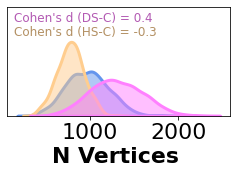

face-v-all Lateral rh 


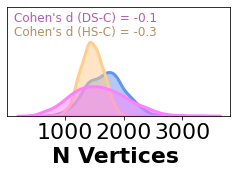

face-v-all Ventral_NoATL lh 


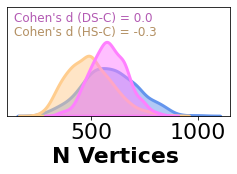

face-v-all Ventral_NoATL rh 


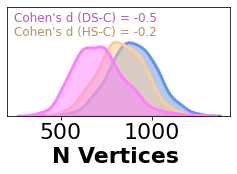

hand-v-nonlimb Lateral lh 


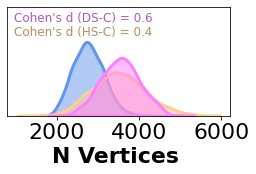

hand-v-nonlimb Lateral rh 


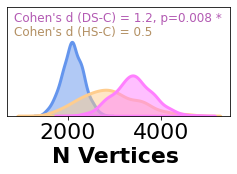

hand-v-nonlimb Ventral_NoATL lh 


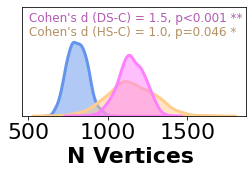

hand-v-nonlimb Ventral_NoATL rh 


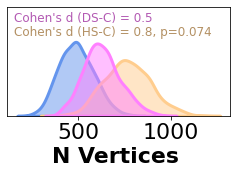

house-v-all Lateral lh 


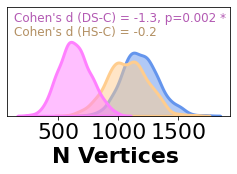

house-v-all Lateral rh 


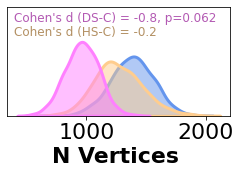

house-v-all Ventral_NoATL lh 


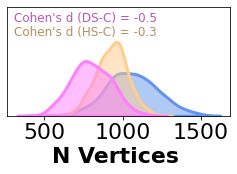

house-v-all Ventral_NoATL rh 


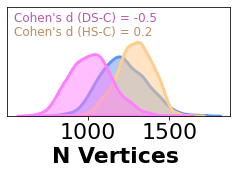

In [17]:
# With or without stats, wide or square panels
plot_KDE(path_results, table_Nverts, cat, group_order, wide = 1, wstats = df_stats)

### Bonus: Visualize group differences 

<ipython-input-14-4e7fb9a2fd52>:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.subplots(figsize=(4,4))


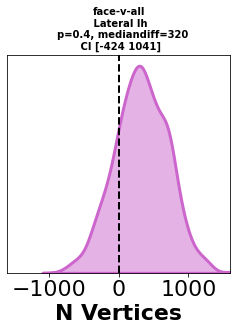

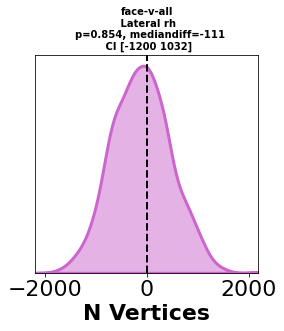

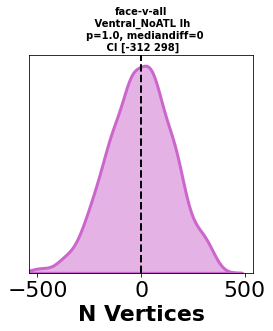

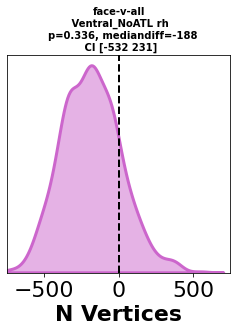

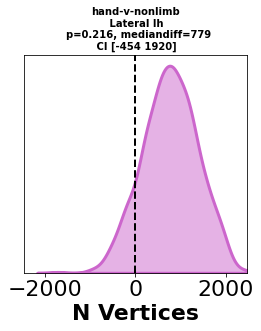

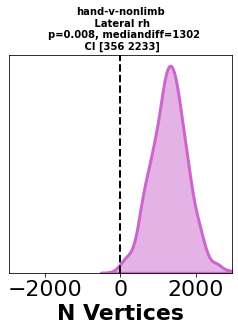

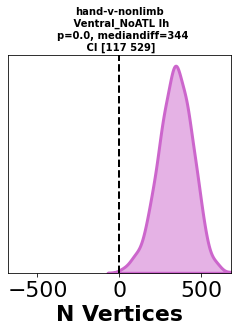

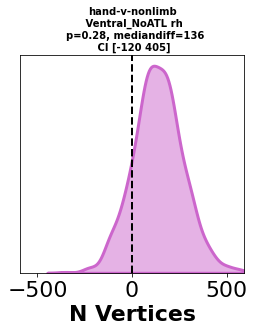

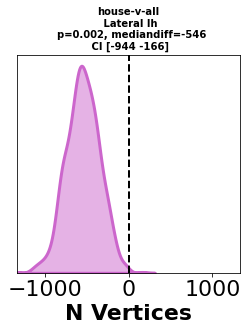

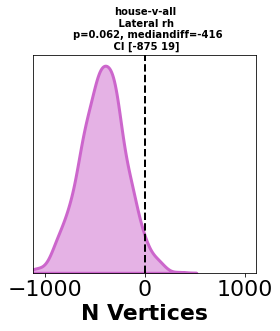

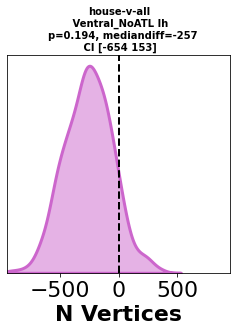

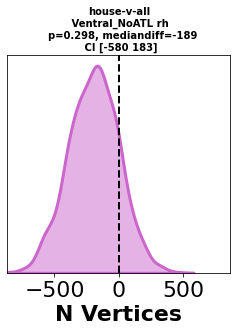

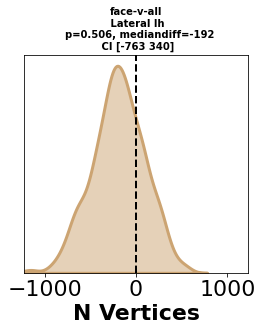

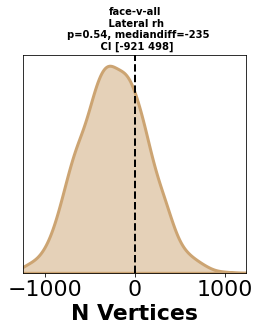

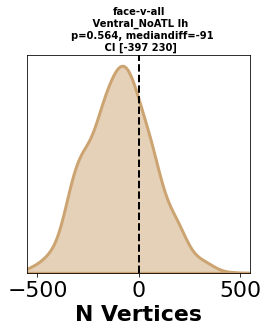

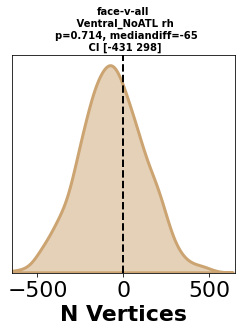

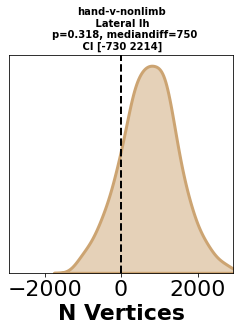

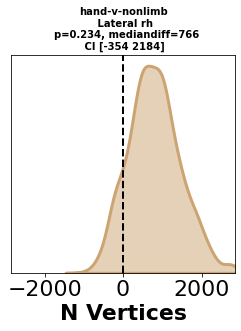

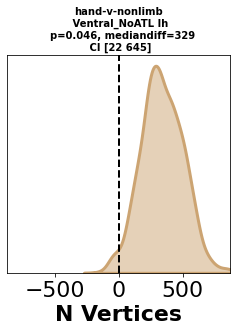

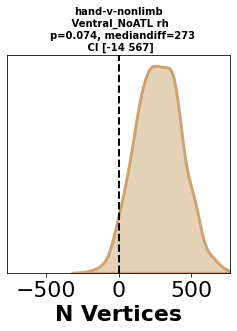

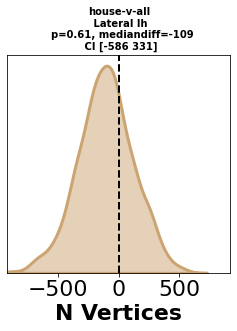

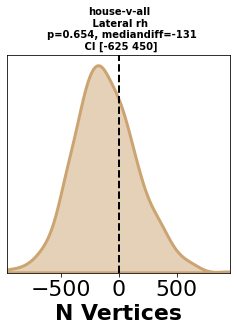

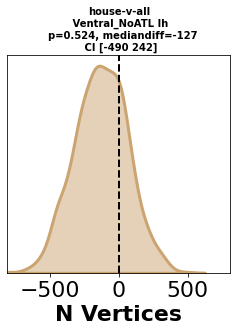

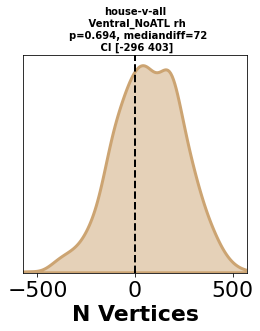

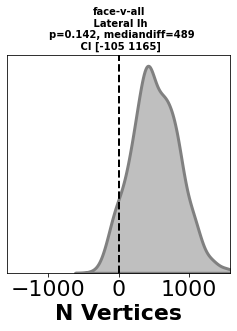

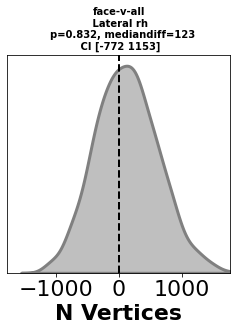

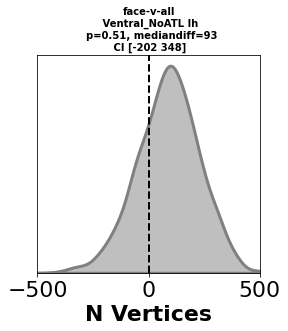

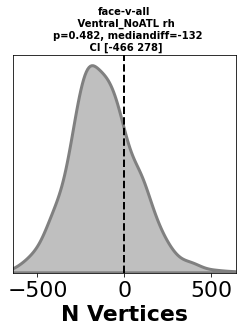

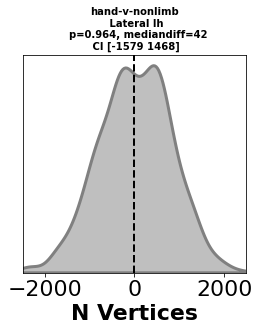

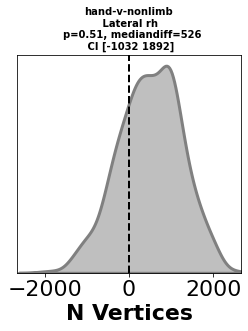

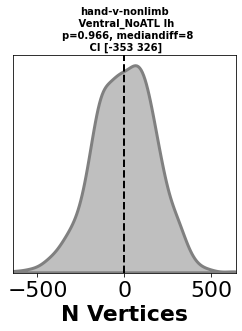

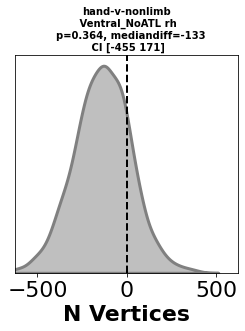

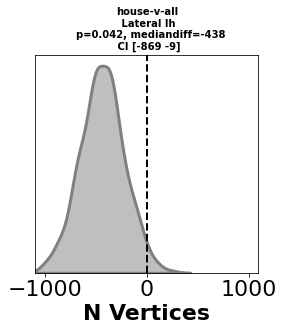

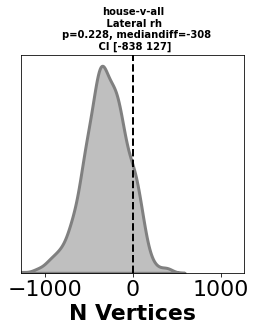

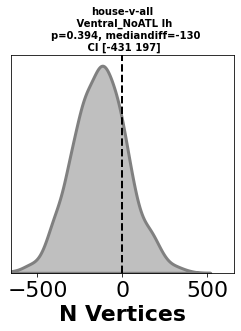

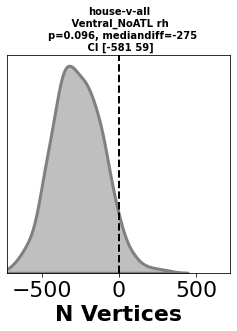

In [18]:
dep_measure = 'Nverts'
x_label = 'N Vertices'

# Plot group differences separately per group 
group_comp = ['DC'] 
comp_name = 'DC'
grpcmp_palette = ['#cc66cc'] # 20% darker 
df_stats_DC = plot_group_diff(df_boots_diff, cats, group_comp,comp_name, grpcmp_palette,dep_measure,x_label)


group_comp = ['HC']
comp_name = 'HC'
grpcmp_palette = ['#cca472'] # 20% darker 
df_stats_HC = plot_group_diff(df_boots_diff, cats, group_comp,comp_name, grpcmp_palette,dep_measure,x_label)

group_comp = ['DH'] 
comp_name = 'DH'
grpcmp_palette = ['grey']  
df_stats_DH = plot_group_diff(df_boots_diff, cats, group_comp,comp_name, grpcmp_palette,dep_measure,x_label)
